# Ping Pong Ball Prediction Using Transfer Learning:

Inputs:
- x y z (frame 1)
- x y z (frame 2)
- x y z (frame 3)
- x y z (frame 4)
- x y z (frame 5)
- x y z (frame 6)
- dt12
- dt23
- dt34
- dt45
- dt56


Outputs:
- x y z (interception)
- vx vy vz
- t_hit



## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

### Importing the Dataset

In [2]:
dataset = pd.read_csv('../learning_data/synthetic_data/synthetic_intercept_dataset.csv')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     20000 non-null  float64
 1   y1                     20000 non-null  float64
 2   z1                     20000 non-null  float64
 3   x2                     20000 non-null  float64
 4   y2                     20000 non-null  float64
 5   z2                     20000 non-null  float64
 6   x3                     20000 non-null  float64
 7   y3                     20000 non-null  float64
 8   z3                     20000 non-null  float64
 9   x4                     20000 non-null  float64
 10  y4                     20000 non-null  float64
 11  z4                     20000 non-null  float64
 12  x5                     20000 non-null  float64
 13  y5                     20000 non-null  float64
 14  z5                     20000 non-null  float64
 15  x6

In [4]:
dataset.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,bounces_before_hit,has_bounce_before_hit,intercept_valid,x0,y0,z0,vx0,vy0,vz0,gravity_z_mm_s2
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.0,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,7.068292,2591.388830,-801.778330,6.553479,2521.003765,-831.446025,6.000961,2450.616336,-858.150963,5.451178,...,1.159400,0.958600,1.0,7.078525,2591.391281,-801.796337,-33.894861,-4539.175912,-2005.071005,-9810.947792
std,610.679866,376.551846,201.914812,588.771715,399.036954,200.032669,567.675558,422.297959,195.157172,547.651975,...,0.465621,0.199219,0.0,610.719670,376.576567,201.888597,2051.488625,1854.297692,1792.989469,98.700253
min,-1062.500000,1940.000000,-1150.740000,-1063.740312,1768.835485,-1155.717344,-1064.833344,1610.060289,-1159.296759,-1068.589318,...,0.000000,0.000000,1.0,-1062.379694,1940.017267,-1150.684271,-5169.023451,-10000.000000,-5395.741585,-10156.262197
25%,-517.830459,2264.281909,-976.612505,-498.793167,2174.001923,-1011.228212,-482.664265,2085.402119,-1040.230727,-466.168373,...,1.000000,1.000000,1.0,-517.282678,2264.497117,-976.954961,-1508.435219,-5764.418256,-3532.191206,-9878.111208
50%,4.603084,2590.930535,-802.374104,3.498146,2521.826941,-834.971562,3.077772,2451.751563,-870.655962,4.641546,...,1.000000,1.000000,1.0,3.626248,2590.423845,-802.529142,-28.803126,-4276.540042,-2041.105830,-9810.833769
75%,534.227887,2917.957446,-626.618862,514.516730,2866.825690,-658.088438,494.859881,2816.448613,-692.393360,474.839351,...,1.000000,1.000000,1.0,534.005061,2917.968720,-627.137026,1406.973954,-3103.658560,-566.318857,-9744.570190
max,1062.500000,3240.000000,-450.740000,1060.725563,3223.651805,-417.001147,1063.693006,3206.022616,-398.177289,1059.687023,...,2.000000,1.000000,1.0,1062.309155,3239.937623,-450.766621,5223.973028,-684.056585,2345.115168,-9406.005637


### Pre-Processing

### Separating the Input and Outputs

In [5]:

input_cols_6 = [
    "x1", "y1", "z1",
    "x2", "y2", "z2",
    "x3", "y3", "z3",
    "x4", "y4", "z4",
    "x5", "y5", "z5",
    "x6", "y6", "z6",
    "dt12", "dt23", "dt34", "dt45", "dt56",
]
target_cols = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]

x = dataset[input_cols_6]
y = dataset[target_cols]


In [6]:
# View the inputs
print(x)

               x1           y1           z1          x2           y2  \
0     -129.479967  3054.184385  -663.307493  -78.392620  3018.848225   
1     -637.861911  1949.250735  -596.128987 -597.984756  1815.936296   
2      979.052834  3119.683840  -660.771256  983.138822  3081.808806   
3     -128.385518  1968.579627  -570.773014 -156.373643  1815.070126   
4     -403.140850  2947.653681  -467.407281 -412.745714  2905.260639   
...           ...          ...          ...         ...          ...   
19995  166.491025  3094.359926  -607.163252  161.834570  3056.797230   
19996   64.189001  2198.417476  -672.528466   88.022717  2114.241888   
19997  593.826406  2913.560680  -759.521606  602.157311  2843.210118   
19998  874.866855  2739.168094 -1058.593474  850.605754  2698.958338   
19999 -295.757286  2320.947709  -546.300503 -265.864191  2229.604875   

                z2          x3           y3           z3          x4  ...  \
0      -652.458811  -39.638464  2988.323377  -643.460357  

In [7]:
# View the outputs
print(y)

             x_hit        y_hit        z_hit       vx_hit       vy_hit  \
0      1371.275360  1931.111771  -753.009373  2680.640491 -2009.045581   
1       -22.823035   -92.587337 -1011.055563  2411.262880 -8008.463872   
2       783.865754    -1.575075  -942.801067  -131.777856 -2081.819982   
3      -430.184554   211.177523  -818.315627 -1580.902144 -9246.937796   
4     -1292.354346  -375.047453  -298.971661  -815.864359 -3051.076828   
...            ...          ...          ...          ...          ...   
19995   500.390440    93.193252  -937.822563   353.541788 -3159.409795   
19996   535.618840   463.333673  -368.426002  1747.593846 -6445.772265   
19997   767.090632   -63.703908  -471.011076   265.142704 -4608.709607   
19998  -403.633277   255.638292 -1102.901012 -1765.164291 -3437.635780   
19999   354.640347   535.047746  -257.905803  1924.411285 -5251.072226   

            vz_hit     t_hit  
0      1488.570757  0.479516  
1      3223.440315  0.175534  
2     -2340.831866

In [8]:
x = x.values
y = y.values

### Splitting the Dataset into the Training set and Test set

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Build reachability vector from your full dataset
# (change column name if needed)
r = dataset["is_reachable"].to_numpy().astype(int)

# 2) Split x, y, and r together (important)
x_train, x_test, y_train, y_test, r_train, r_test = train_test_split(
    x, y, r,
    test_size=0.05,
    random_state=2,
    stratify=r   # recommended
)

# 3) Keep full test copy
x_test_all = x_test.copy()
y_test_all = y_test.copy()

# 4) Reachable-only adjusted test set
mask_reach = (r_test == 1)
x_test_reach = x_test_all[mask_reach].copy()
y_test_reach = y_test_all[mask_reach].copy()


In [10]:
print(x_train.shape)
print(x_test_all.shape)
print(x_test_reach.shape)
print(y_train.shape)
print(y_test_all.shape)
print(y_test_reach.shape)

(19000, 23)
(1000, 23)
(234, 23)
(19000, 7)
(1000, 7)
(234, 7)


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scx = StandardScaler()
scy = StandardScaler()

x_train = scx.fit_transform(x_train)
x_test_all = scx.transform(x_test_all)
x_test_reach = scx.transform(x_test_reach)

y_train = scy.fit_transform((y_train))
y_test_all = scy.transform((y_test_all))
y_test_reach = scy.transform((y_test_reach))

## The ANN Model Initialization

In [12]:
ball_predictor = tf.keras.models.Sequential()

### Constructing the Model

In [13]:

ball_predictor.add(tf.keras.layers.Dense(units=23, activation='relu')) # 23 input features (6 points + 5 dt)
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hiddel layer 1
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hidden layer 2
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hiddel layer 3
ball_predictor.add(tf.keras.layers.Dense(units=16, activation='relu')) # hiddel layer 4
ball_predictor.add(tf.keras.layers.Dense(units=7, activation='linear')) # 7


In [14]:
ball_predictor.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])

### Training

In [15]:
p1 = ball_predictor.fit(x_train, y_train, validation_split=0.2, batch_size = 32, epochs = 80,verbose=1)

Epoch 1/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6919 - mean_squared_error: 0.6919 - val_loss: 0.5090 - val_mean_squared_error: 0.5090
Epoch 2/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3744 - mean_squared_error: 0.3744 - val_loss: 0.2871 - val_mean_squared_error: 0.2871
Epoch 3/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2431 - mean_squared_error: 0.2431 - val_loss: 0.2010 - val_mean_squared_error: 0.2010
Epoch 4/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1812 - mean_squared_error: 0.1812 - val_loss: 0.1612 - val_mean_squared_error: 0.1612
Epoch 5/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1548 - mean_squared_error: 0.1548 - val_loss: 0.1476 - val_mean_squared_error: 0.1476
Epoch 6/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1400 - mean_squared_error: 0.1400 - val_loss: 0.1338 - val_mean_squared_error: 0.1338
Epoch 7/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1297 - mean_squared_error: 0.1297 - val_loss: 0.12

### Learning Curves

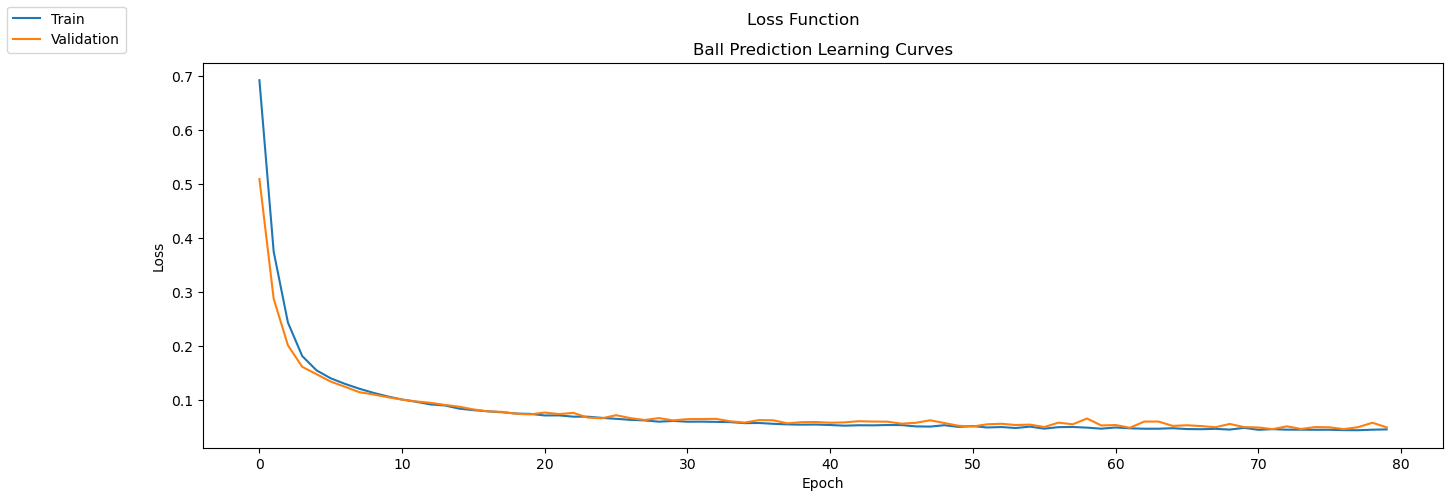

In [16]:
fig, axs = plt.subplots(figsize=(16,5))
fig.suptitle('Loss Function')

axs.plot(p1.history['loss'])
axs.plot(p1.history['val_loss'])
axs.set_title("Ball Prediction Learning Curves")
axs.set(xlabel='Epoch', ylabel='Loss')

fig.legend(labels=['Train', 'Validation'], loc="upper left")
plt.show()

In [17]:
# def eval_regression(name, y_true, y_pred):
#     mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
#     print(f"\n{name}")
#     print("MAE per output:", mae)
#     print("RMSE per output:", rmse)

# # If y is scaled, inverse-transform both y_true and y_pred before metrics.
# y_pred_all = ball_predictor.predict(x_test_all)
# y_pred_reach = ball_predictor.predict(x_test_reach)

# # Example for scaled targets:
# # y_pred_all = scy.inverse_transform(y_pred_all); y_test_all_eval = scy.inverse_transform(y_test_all)
# # y_pred_reach = scy.inverse_transform(y_pred_reach); y_test_reach_eval = scy.inverse_transform(y_test_reach)

# eval_regression("All test shots", y_test_all, y_pred_all)
# eval_regression("Reachable-only test shots", y_test_reach, y_pred_reach)

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

target_names = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]
target_units = ["mm", "mm", "mm", "mm/s", "mm/s", "mm/s", "ms"]

def eval_with_units(name, model, x_eval, y_eval, y_scaler, y_is_scaled=True, t_hit_in_seconds=True):
    y_pred = model.predict(x_eval, verbose=0)

    # Convert to physical units exactly once
    if y_is_scaled:
        assert y_eval.shape[1] == y_scaler.n_features_in_ == len(target_names)
        y_true_u = y_scaler.inverse_transform(y_eval)
        y_pred_u = y_scaler.inverse_transform(y_pred)
    else:
        y_true_u = y_eval
        y_pred_u = y_pred

    err = y_pred_u - y_true_u
    abs_err = np.abs(err)

    mae = mean_absolute_error(y_true_u, y_pred_u, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true_u, y_pred_u, multioutput="raw_values"))
    std_abs = abs_err.std(axis=0)

    # Convert t_hit to ms for reporting (only if stored in seconds)
    if t_hit_in_seconds:
        i = target_names.index("t_hit")
        mae[i] *= 1000.0
        rmse[i] *= 1000.0
        std_abs[i] *= 1000.0

    report = pd.DataFrame({
        "target": target_names,
        "unit": target_units,
        "MAE": mae,
        "RMSE": rmse,
        "STD_abs_error": std_abs,
    })

    print(f"\n{name}")
    print(report.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

# Run both:
eval_with_units("All test shots", ball_predictor, x_test_all, y_test_all, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Reachable-only test shots", ball_predictor, x_test_reach, y_test_reach, scy, y_is_scaled=True, t_hit_in_seconds=True)




All test shots
target unit     MAE    RMSE  STD_abs_error
 x_hit   mm  85.132 110.224         70.013
 y_hit   mm  82.498 116.663         82.488
 z_hit   mm  57.151  76.248         50.473
vx_hit mm/s 169.413 216.004        134.003
vy_hit mm/s 136.204 179.895        117.518
vz_hit mm/s 454.262 883.247        757.477
 t_hit   ms  28.414  40.625         29.035

Reachable-only test shots
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  78.730    99.690         61.153
 y_hit   mm  96.243   134.389         93.795
 z_hit   mm  39.997    51.492         32.428
vx_hit mm/s 167.356   222.061        145.956
vy_hit mm/s 120.515   162.042        108.323
vz_hit mm/s 584.188 1,256.112      1,111.999
 t_hit   ms  28.046    38.361         26.173


In [18]:
# Verification 
train_std = scy.scale_ 
rmse_sigma = np.sqrt(0.1084)   # val_mse from curve, e.g. 0.1151
rmse_units = rmse_sigma * train_std

print(rmse_units)


[2.48307643e+02 1.76233286e+02 1.18205970e+02 6.75278705e+02
 6.10470724e+02 7.15709676e+02 9.36828249e-02]


## Loading the Matched Synthetic Dataset (Transfer Learning)

In [19]:
matched_dataset = pd.read_csv('../learning_data/synthetic_matched_data/synthetic_intercept_dataset.csv')
matched_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     10000 non-null  float64
 1   y1                     10000 non-null  float64
 2   z1                     10000 non-null  float64
 3   x2                     10000 non-null  float64
 4   y2                     10000 non-null  float64
 5   z2                     10000 non-null  float64
 6   x3                     10000 non-null  float64
 7   y3                     10000 non-null  float64
 8   z3                     10000 non-null  float64
 9   x4                     10000 non-null  float64
 10  y4                     10000 non-null  float64
 11  z4                     10000 non-null  float64
 12  x5                     10000 non-null  float64
 13  y5                     10000 non-null  float64
 14  z5                     10000 non-null  float64
 15  x6 

In [20]:

input_cols_6 = [
    "x1", "y1", "z1",
    "x2", "y2", "z2",
    "x3", "y3", "z3",
    "x4", "y4", "z4",
    "x5", "y5", "z5",
    "x6", "y6", "z6",
    "dt12", "dt23", "dt34", "dt45", "dt56",
]
target_cols = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]

x_matched = matched_dataset[input_cols_6]
y_matched = matched_dataset[target_cols]


# View the inputs
print(x_matched)
print(y_matched)

x_matched = x_matched.values
y_matched = y_matched.values


              x1           y1           z1          x2           y2  \
0    -112.391815  3050.725773  -706.693061  -88.727903  3031.103228   
1    -882.316974  2974.973326  -736.689106 -860.651911  2944.684412   
2     364.125980  2428.744532  -542.984599  357.734579  2357.293555   
3     715.945998  2295.088042  -799.753080  707.017804  2260.188210   
4       5.425217  2302.356572 -1143.417017  -15.835511  2255.025579   
...          ...          ...          ...         ...          ...   
9995 -570.644257  2287.035775  -871.230644 -556.452934  2228.173480   
9996  791.007658  2170.154020  -687.034060  791.530872  2126.485900   
9997   29.344317  2753.705662  -845.120499   10.313566  2703.831106   
9998  599.256061  2854.885066 -1072.818767  579.432601  2811.895649   
9999  264.670911  3083.251237  -877.475339  264.213412  3043.888668   

               z2          x3           y3           z3          x4  ...  \
0     -702.164940  -60.733193  3011.605060  -691.422320  -36.761516  ..

In [21]:
#Split input and output x, y
x_matched_train, x_matched_test, y_matched_train, y_matched_test= train_test_split(
    x_matched, y_matched,
    test_size=0.1,
    random_state=2
    
)

In [22]:
print(x_matched_train.shape)
print(x_matched_test.shape)
print(y_matched_train.shape)
print(y_matched_test.shape)

x_matched_train_s = scx.transform(x_matched_train)
x_matched_test_s = scx.transform(x_matched_test)
y_matched_train_s = scy.transform(y_matched_train)
y_matched_test_s = scy.transform(y_matched_test)

(9000, 23)
(1000, 23)
(9000, 7)
(1000, 7)


In [23]:
# from tensorflow.keras.optimizers import Adam
# import tensorflow as tf

# # Start from synthetic-pretrained weights
# transfer_model_matched = tf.keras.models.clone_model(ball_predictor)
# transfer_model_matched.set_weights(ball_predictor.get_weights())

# # Freezing layers
# for layer in transfer_model_matched.layers[:1]:
#     layer.trainable = False

# transfer_model_matched.compile(
#     loss="mean_squared_error",
#     optimizer=Adam(learning_rate=1e-3),
#     metrics=["mean_squared_error"]
# )

# history_matched = transfer_model_matched.fit(
#     x_matched_train_s, y_matched_train_s,
#     validation_split=0.2,
#     epochs=100,
#     verbose=1
# )

## Regularization
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

# Try 1e-5 first; then tune [1e-6, 1e-5, 5e-5]
L2_LAMBDA = 3e-4

dense_total = sum(isinstance(l, tf.keras.layers.Dense) for l in ball_predictor.layers)
dense_seen = {"n": 0}

def clone_with_l2(layer):
    cfg = layer.get_config()
    if isinstance(layer, tf.keras.layers.Dense):
        dense_seen["n"] += 1
        is_output_layer = (dense_seen["n"] == dense_total)
        if not is_output_layer:  # regularize hidden layers only
            cfg["kernel_regularizer"] = regularizers.serialize(regularizers.l2(L2_LAMBDA))
    return layer.__class__.from_config(cfg)

# Start from broad pretrained model, but with L2 regularization added
transfer_model_matched = tf.keras.models.clone_model(
    ball_predictor,
    clone_function=clone_with_l2
)
transfer_model_matched.set_weights(ball_predictor.get_weights())

for layer in transfer_model_matched.layers[:3]:
    layer.trainable = False

transfer_model_matched.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["mean_squared_error"]
)

history_matched = transfer_model_matched.fit(
    x_matched_train_s, y_matched_train_s,
    validation_split=0.2,
    epochs=100,
    verbose=1
)


Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1615 - mean_squared_error: 0.1236 - val_loss: 0.1405 - val_mean_squared_error: 0.1064
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1343 - mean_squared_error: 0.1027 - val_loss: 0.1313 - val_mean_squared_error: 0.1018
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1278 - mean_squared_error: 0.0999 - val_loss: 0.1272 - val_mean_squared_error: 0.1008
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1241 - mean_squared_error: 0.0989 - val_loss: 0.1257 - val_mean_squared_error: 0.1017
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1214 - mean_squared_error: 0.0982 - val_loss: 0.1212 - val_mean_squared_error: 0.0989
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1202 - mean_squared_error: 0.0987 - val_loss: 0.1200 - val_mean_squared_error: 0.0991
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1182 - mean_squared_error: 0.0979 - val_los

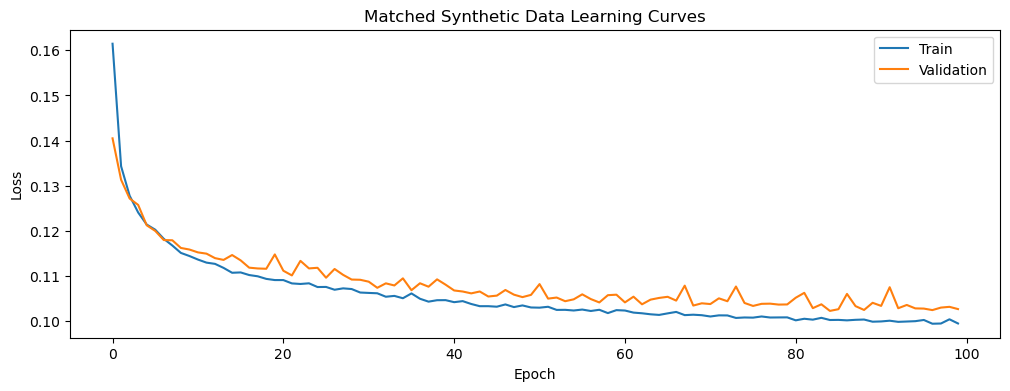

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_matched.history["loss"], label="Train")
ax.plot(history_matched.history["val_loss"], label="Validation")
ax.set_title("Matched Synthetic Data Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

In [25]:
eval_with_units(
    "Matched Data Transfer Model",
    transfer_model_matched,
    x_matched_test_s,
    y_matched_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)


Matched Data Transfer Model
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  83.584   109.546         70.811
 y_hit   mm 132.080   178.766        120.467
 z_hit   mm  99.150   132.296         87.586
vx_hit mm/s  96.424   122.554         75.643
vy_hit mm/s  95.492   121.581         75.255
vz_hit mm/s 762.520 1,136.608        842.877
 t_hit   ms  55.033    83.540         62.851


## Loading the Real Dataset (Transfer Learning)

In [26]:
real_dataset = pd.read_csv('../learning_data/real_data/real_transfer_dataset_clean.csv')
real_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_id           112 non-null    int64  
 1   captured_at         112 non-null    object 
 2   x1                  112 non-null    float64
 3   y1                  112 non-null    float64
 4   z1                  112 non-null    float64
 5   x2                  112 non-null    float64
 6   y2                  112 non-null    float64
 7   z2                  112 non-null    float64
 8   x3                  112 non-null    float64
 9   y3                  112 non-null    float64
 10  z3                  112 non-null    float64
 11  x4                  112 non-null    float64
 12  y4                  112 non-null    float64
 13  z4                  112 non-null    float64
 14  x5                  112 non-null    float64
 15  y5                  112 non-null    float64
 16  z5      

In [27]:
real_dataset.describe()

,sample_id,x1,y1,z1,x2,y2,z2,x3,y3,z3,...,x_hit,y_hit,z_hit,vx_hit,vy_hit,vz_hit,t_hit,is_reachable,intercept_valid,bounces_before_hit
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,...,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.0,112.000000
mean,60.517857,100.857821,2483.328348,-733.317857,107.002641,2402.224493,-742.006430,104.733839,2319.117632,-751.639136,...,70.070608,87.302517,-879.866712,-19.537561,-2332.214701,-165.717481,0.608252,0.839286,1.0,0.303571
std,34.786086,307.902912,127.380579,190.183754,301.008965,129.337364,201.532823,298.786754,129.975399,210.701607,...,373.019132,146.633755,79.064664,504.048177,985.543646,1331.171090,0.186569,0.368918,0.0,0.550827
min,1.000000,-612.631405,1273.071997,-1072.673118,-592.774694,1204.964430,-1116.253325,-621.932816,1171.607007,-1121.853324,...,-862.743222,-287.305835,-1093.444005,-2161.406732,-5256.219585,-3394.900796,0.258700,0.000000,1.0,0.000000
25%,30.750000,-139.598200,2458.719341,-900.522143,-123.561113,2372.633591,-915.933438,-132.597624,2284.563316,-940.187264,...,-189.318941,-10.248857,-931.822881,-308.202733,-2800.505316,-1288.530443,0.482062,1.000000,1.0,0.000000
50%,62.500000,107.224175,2495.282966,-687.390236,119.452177,2423.193874,-680.177794,117.802878,2341.232055,-701.026327,...,71.730358,53.929018,-882.434594,-22.879361,-2311.871659,-185.172900,0.607542,1.000000,1.0,0.000000
75%,90.250000,361.682736,2531.966223,-585.584152,361.987865,2455.660422,-579.335432,360.415064,2380.544151,-590.763504,...,355.005867,188.400860,-818.443254,301.761440,-1791.731222,1036.167229,0.714401,1.000000,1.0,1.000000
max,119.000000,653.558850,2641.400114,-246.752258,655.894454,2563.067314,-261.652908,642.288845,2477.851190,-278.030276,...,691.626682,438.189492,-664.134742,1209.529463,1385.489985,2544.768002,1.434387,1.000000,1.0,2.000000


### Pre-Processing the Real Dataset

In [28]:

input_cols_6 = [
    "x1", "y1", "z1",
    "x2", "y2", "z2",
    "x3", "y3", "z3",
    "x4", "y4", "z4",
    "x5", "y5", "z5",
    "x6", "y6", "z6",
    "dt12", "dt23", "dt34", "dt45", "dt56",
]
target_cols = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]

x_real = real_dataset[input_cols_6]
y_real = real_dataset[target_cols]


In [29]:
# View the inputs
print(x_real)

             x1           y1           z1          x2           y2  \
0   -147.363672  2460.850367  -948.340768 -141.441986  2373.584399   
1    140.284261  2545.655419  -942.503600  135.195755  2460.035487   
2    -82.170265  2502.640014 -1035.591182  -47.387515  2418.330443   
3    -92.978785  2459.279867  -994.203977  -99.581842  2362.319538   
4    651.384358  2575.633941  -925.660916  645.211924  2496.134878   
..          ...          ...          ...         ...          ...   
107 -212.922463  2398.957405  -643.186900 -178.978695  2304.123993   
108  373.745015  2541.794915  -611.606577  380.709403  2473.578448   
109 -272.058365  2422.013068  -625.817689 -270.311916  2350.598164   
110   -5.004679  2472.742000  -557.154847  -32.201254  2404.576799   
111 -482.096218  2429.259455  -815.986927 -498.369086  2339.430347   

              z2          x3           y3           z3          x4  ...  \
0    -990.575059 -134.366635  2286.373730 -1036.273480 -119.054987  ...   
1    -982

In [30]:
# View the inputs
print(y_real)

          x_hit       y_hit        z_hit       vx_hit       vy_hit  \
0    123.424780   59.140150  -917.170360   561.665855 -1488.826429   
1    -81.255717   12.316043  -858.682729    -5.427189 -1767.051436   
2    587.095454  314.865457  -858.163759   805.030777 -2144.261541   
3   -198.621419  -39.003980  -910.217430  -131.436385 -2401.804900   
4    609.934981  277.678848  -850.612559   218.946215 -1518.182302   
..          ...         ...          ...          ...          ...   
107  185.997001    0.853678  -801.083691   196.117435 -3375.038714   
108   90.861379  -30.037610  -867.827495  -394.568437 -2309.445419   
109 -274.632941  -40.973615  -888.929979  -721.962797 -3119.507003   
110 -862.743222  390.574757  -719.939050 -1091.160325 -2231.806638   
111 -623.648384  186.151766 -1000.620719  -412.112298 -3118.613483   

          vz_hit     t_hit  
0    1356.633250  0.607091  
1     563.475630  0.673253  
2    1080.108070  0.619194  
3    1315.832490  0.589168  
4     810.6165

In [31]:
x_real = x_real.values
y_real = y_real.values

### Splitting the Dataset into the Training set and Test set

In [32]:
#Split input and output x, y
x_real_train, x_real_test, y_real_train, y_real_test= train_test_split(
    x_real, y_real,
    test_size=0.2,
    random_state=2
    

)


In [33]:
print(x_real_train.shape)
print(x_real_test.shape)
print(y_real_train.shape)
print(y_real_test.shape)

(89, 23)
(23, 23)
(89, 7)
(23, 7)


### Scaling the real dataset

In [34]:
x_real_train_s = scx.transform(x_real_train)
x_real_test_s = scx.transform(x_real_test)
y_real_train_s = scy.transform(y_real_train)
y_real_test_s = scy.transform(y_real_test)

In [35]:
# ### WEighting the xyz more than velocities

# # Output order must match your y columns:
# # [x_hit, y_hit, z_hit, vx_hit, vy_hit, vz_hit, t_hit]
# raw_w = tf.constant([10.0, 10.0, 10.0, 1.0, 1.0, 1.0, 5.0], dtype=tf.float32)

# # normalize so average weight is ~1 (keeps loss scale stable)
# output_weights = raw_w / tf.reduce_mean(raw_w)

# def weighted_mse(y_true, y_pred):
#     err2 = tf.square(y_true - y_pred)              # (batch, 7)
#     weighted_err2 = err2 * output_weights          # broadcast on 7 outputs
#     return tf.reduce_mean(weighted_err2)



## Training the New Layers (Classification Layers)

In [36]:


# Start from synthetic-pretrained weights
transfer_model = tf.keras.models.clone_model(transfer_model_matched)
transfer_model.set_weights(transfer_model_matched.get_weights())

# Stage 1: freeze first 2 layers
for layer in transfer_model.layers[:2]:
    layer.trainable = False

transfer_model.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=5e-4),
    metrics=["mean_squared_error"]
)

# ###Weighted 
# transfer_model.compile(
#     loss=weighted_mse,
#     optimizer=Adam(learning_rate=5e-4),
#     metrics=["mean_squared_error"]  # still logs normal MSE too
# )


history_stage1 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    validation_split=0.2,
    epochs=150,
    verbose=1
)





Epoch 1/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - loss: 0.5942 - mean_squared_error: 0.5879 - val_loss: 0.7133 - val_mean_squared_error: 0.7070
Epoch 2/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5103 - mean_squared_error: 0.5040 - val_loss: 0.6248 - val_mean_squared_error: 0.6185
Epoch 3/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4377 - mean_squared_error: 0.4314 - val_loss: 0.5482 - val_mean_squared_error: 0.5419
Epoch 4/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3768 - mean_squared_error: 0.3705 - val_loss: 0.4846 - val_mean_squared_error: 0.4783
Epoch 5/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3264 - mean_squared_error: 0.3201 - val_loss: 0.4326 - val_mean_squared_error: 0.4264
Epoch 6/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.2853 - mean_squared_error: 0.2791 - val_loss: 0.3911 - val_mean_squared_error: 0.3849
Epoch 7/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2532 - mean_squared_error: 0.2470 - val_loss: 0.3585 - val_mean

## Stage 1 Validation Curve

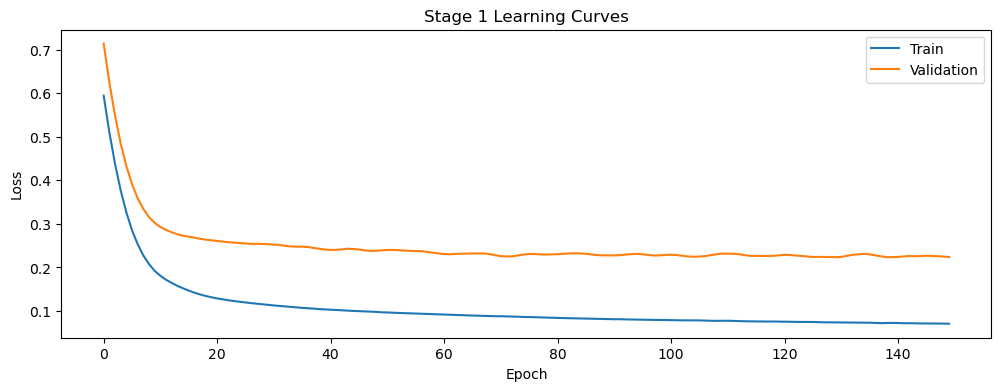

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage1.history["loss"], label="Train")
ax.plot(history_stage1.history["val_loss"], label="Validation")
ax.set_title("Stage 1 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [38]:
eval_with_units(
    "Stage 1 Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 1 Transfer Model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    91.445   158.131        129.008
 y_hit   mm    85.503   111.149         71.016
 z_hit   mm    67.363    78.961         41.195
vx_hit mm/s   302.314   377.521        226.115
vy_hit mm/s   515.344   635.558        371.961
vz_hit mm/s 1,141.951 1,410.041        827.142
 t_hit   ms    57.519    83.001         59.839


In [39]:


def snapshot_model(model):
    m = tf.keras.models.clone_model(model)
    m.set_weights(model.get_weights())
    return m

# # Weighted Version
# def snapshot_model(model):
#     with tf.keras.utils.custom_object_scope({'weighted_mse': weighted_mse}):
#         m = tf.keras.models.clone_model(model)
#     m.set_weights(model.get_weights())
#     return m
    
# --- run this RIGHT AFTER stage 1 training/eval ---
stage1_model = snapshot_model(transfer_model)
print("Saved stage1_model snapshot.")


Saved stage1_model snapshot.


In [40]:
# Stage 2: unfreeze all layers
for layer in transfer_model.layers:
    layer.trainable = True

transfer_model.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=1e-5),
    metrics=["mean_squared_error"]
)

# ###Weighted 
# transfer_model.compile(
#     loss=weighted_mse,
#     optimizer=Adam(learning_rate=1e-5),
#     metrics=["mean_squared_error"]
# )


history_stage2 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    validation_split=0.2,
    epochs=300,
    verbose=1
)



Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - loss: 0.1253 - mean_squared_error: 0.0655 - val_loss: 0.2784 - val_mean_squared_error: 0.2186
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1251 - mean_squared_error: 0.0654 - val_loss: 0.2784 - val_mean_squared_error: 0.2186
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1250 - mean_squared_error: 0.0653 - val_loss: 0.2785 - val_mean_squared_error: 0.2188
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1250 - mean_squared_error: 0.0652 - val_loss: 0.2786 - val_mean_squared_error: 0.2188
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1249 - mean_squared_error: 0.0651 - val_loss: 0.2786 - val_mean_squared_error: 0.2189
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1248 - mean_squared_error: 0.0650 - val_loss: 0.2787 - val_mean_squared_error: 0.2189
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1247 - mean_squared_error: 0.0650 - val_loss: 0.2788 - val_mean

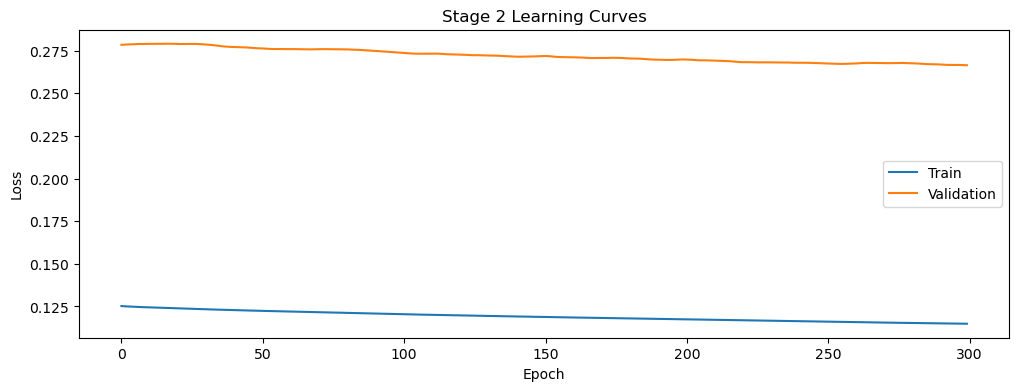

In [41]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage2.history["loss"], label="Train")
ax.plot(history_stage2.history["val_loss"], label="Validation")
ax.set_title("Stage 2 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [42]:
eval_with_units(
    "Stage 2 Final Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 2 Final Transfer Model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    91.935   166.477        138.789
 y_hit   mm    86.317   107.257         63.667
 z_hit   mm    65.359    74.590         35.943
vx_hit mm/s   286.312   362.456        222.262
vy_hit mm/s   512.626   624.008        355.810
vz_hit mm/s 1,088.062 1,325.218        756.520
 t_hit   ms    49.570    72.915         53.474


In [43]:
stage2_model = snapshot_model(transfer_model)
print("Saved stage2_model snapshot.")

# --- run once (any time after broad + matched are trained) ---
broad_model = snapshot_model(ball_predictor)
matched_model = snapshot_model(transfer_model_matched)
print("Saved broad_model and matched_model snapshots.")




Saved stage2_model snapshot.
Saved broad_model and matched_model snapshots.


In [44]:
# --- final comparison on real test set ---
eval_with_units("Broad model - Real Test",   broad_model,   x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Matched model - Real Test", matched_model, x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Stage 1 model - Real Test", stage1_model,  x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Stage 2 model - Real Test", stage2_model,  x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)




Broad model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    78.958   160.844        140.131
 y_hit   mm   128.242   164.304        102.713
 z_hit   mm   142.052   187.823        122.878
vx_hit mm/s   458.018   569.967        339.237
vy_hit mm/s 2,866.986 2,964.244        753.084
vz_hit mm/s 2,062.106 2,341.627      1,109.475
 t_hit   ms   205.723   232.477        108.275

Matched model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    97.172   139.900        100.646
 y_hit   mm   118.834   155.991        101.054
 z_hit   mm   124.710   180.923        131.075
vx_hit mm/s   474.795   553.291        284.079
vy_hit mm/s 2,882.657 2,973.720        730.274
vz_hit mm/s 1,916.892 2,209.520      1,098.866
 t_hit   ms   217.467   242.855        108.105

Stage 1 model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    91.445   158.131        129.008
 y_hit   mm    85.503   111.149         71.016
 z_hit   mm    67.363    78.

In [45]:
from pathlib import Path
import joblib

export_dir = Path("../models/ann_stage2_6pt")
export_dir.mkdir(parents=True, exist_ok=True)

deploy_model = stage2_model   # or transfer_model / matched_model / broad_model
deploy_model.save(export_dir / "ball_predictor.keras")
joblib.dump(scx, export_dir / "scx.joblib")
joblib.dump(scy, export_dir / "scy.joblib")

print("Saved model + scalers to:", export_dir.resolve())


Saved model + scalers to: C:\Users\rocky\Personal\UBC\Year 4\IGEN 430\TableTennis_Software_Firmware\transfer_learning\models\ann_stage2_6pt
